# Calgary Crime Data Analysis and Neural Network Prediction

## Data Features

| Column Name | Description |
| --- | --- |
|Community Name| The name of the community in Calgary|
|Category| The type of crime that occurred|
|Crime Count| The number of crimes that occurred in that month|
|Year| The year the crime occurred|
|Month| The month the crime occurred|

Category - Target Variable and Remaining all other Feature are Independent Variable

## Strategy
1. Loading the data and understanding the data
2. Data Preprocessing - cleaing the data and preparing it for analysis
3. Exploratory Data Analysis - Analyzing the data to understand the trends and patterns
4. Building a Neural Network Model
5. Optimizing the model
6. Training the model
7. Predicting the number of crimes that will occur in the future

### Importing Libraies

In [5]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Load the Dataset

In [7]:
# Load the Dataset
df = pd.read_csv('Community_Crime_Statistics_20240522.csv')

In [8]:
# Show the first five rows of the dataset
df.head()

,Community,Category,Crime Count,Year,Month
0,01B,Assault (Non-domestic),1,2022,11
1,01B,Break & Enter - Commercial,1,2019,6
2,01B,Break & Enter - Commercial,1,2019,8
3,01B,Break & Enter - Commercial,2,2020,3
4,01B,Break & Enter - Commercial,2,2020,7


In [9]:
# show the last five rows of the dataset
df.tail()

,Community,Category,Crime Count,Year,Month
70656,SCARBORO/ SUNALTA WEST,Violence 'Other' (Non-domestic),1,2018,8
70657,SCARBORO/ SUNALTA WEST,Violence 'Other' (Non-domestic),1,2019,1
70658,SCARBORO/ SUNALTA WEST,Violence 'Other' (Non-domestic),1,2019,3
70659,SCARBORO/ SUNALTA WEST,Violence 'Other' (Non-domestic),1,2019,11
70660,01H,Theft OF Vehicle,1,2021,10


### Data Preprocessing

In [11]:
# Shape of the dataset
df.shape

(70661, 5)

We have 70661 Rows and 5 Columns

In [13]:
# Checking Data Types of the dataset
df.dtypes

Community      object
Category       object
Crime Count     int64
Year            int64
Month           int64
dtype: object

In [14]:
# Show the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70661 entries, 0 to 70660
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Community    70661 non-null  object
 1   Category     70661 non-null  object
 2   Crime Count  70661 non-null  int64 
 3   Year         70661 non-null  int64 
 4   Month        70661 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 2.7+ MB


In [15]:
# Display the columns of the dataset
df.columns

Index(['Community', 'Category', 'Crime Count', 'Year', 'Month'], dtype='object')

In [16]:
# Remove the white space in column 'Crime Count'
df.columns = df.columns.str.strip().str.replace('Crime Count', 'Crime_Count')

# Rechecking the columns names
df.columns

Index(['Community', 'Category', 'Crime_Count', 'Year', 'Month'], dtype='object')

In [17]:
# Show the statistical summary of the dataset
df.describe()

,Crime_Count,Year,Month
count,70661.000000,70661.000000,70661.000000
mean,2.855748,2020.618616,6.369242
std,3.664965,1.825330,3.451445
min,1.000000,2018.000000,1.000000
25%,1.000000,2019.000000,3.000000
50%,2.000000,2021.000000,6.000000
75%,3.000000,2022.000000,9.000000
max,111.000000,2024.000000,12.000000


In [18]:
# Statitical summary of categorical column
df.describe(include = 'object')

,Community,Category
count,70661,70661
unique,296,9
top,BELTLINE,Theft FROM Vehicle
freq,628,15323


In [19]:
# checking duplicates
df.duplicated().sum()

0

There are no duplicate records in the dataset

In [21]:
# checking missing values in the dataset
df.isnull().sum()

Community      0
Category       0
Crime_Count    0
Year           0
Month          0
dtype: int64

There are no missing values in the dataset

## Exploratory Data Analysis

In the exploraotry data analysis, I will be analyzing the data to understand the trends and patterns in the data. Through this analysis, I will be able to understand the data better and build a better model for prediction.

### Community Distribution

In [25]:
# Checking the number of unique communities in the dataset
df['Community'].nunique()

296

That means there are 296 unique communities in the dataset.

Text(0, 0.5, '')

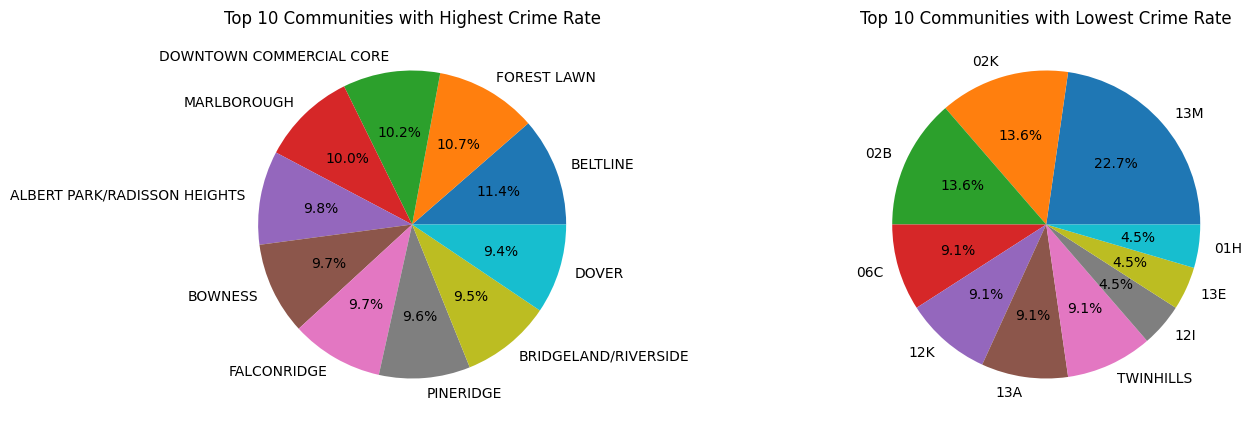

In [27]:
fig, ax = plt. subplots(1, 2, figsize = (15, 5))

# Top 10 Communities with Highest Crime Rate
df['Community'].value_counts().head(10).plot.pie(autopct = '%1.1f%%', ax = ax[0])
ax[0].set_title('Top 10 Communities with Highest Crime Rate')
ax[0].set_ylabel('')

# Top 10 Communities with Lowest Crime Rate
df['Community'].value_counts().tail(10).plot.pie(autopct = '%1.1f%%', ax = ax[1])
ax[1].set_title('Top 10 Communities with Lowest Crime Rate')
ax[1].set_ylabel('')

These pie charts show the distribution of crimes in each community. The first pie chart shows the top 10 most dangerous communities in Calgary with highest crime rate. The second pie chart shows the distribution of top 10 safest communities in Calgary that is lowest crime rate. In the first pie chart, Beltline is the most dangerous community in Calgary with 11.4% of the top crimes in number, followed by Forest Lawn with 10.7% and Downtown Commercial Core with 10.2%. In the second pie chart, the safest community is 13M with 22.7% of the least crimes in number, followed by 02K with 13.6% and 02B with 13.6%.

This is note that all these observations are without any bias and completely based on the data from the city of Calgary website.

### Crime Category Distribution

In [30]:
# Checking the number of unique Crime Categories in the dataset
print(df['Category'].nunique())

# Displaying the unique crime category names
print(df['Category'].unique())

9
['Assault (Non-domestic)' 'Break & Enter - Commercial'
 'Break & Enter - Dwelling' 'Theft FROM Vehicle' 'Theft OF Vehicle'
 "Violence\xa0 'Other' (Non-domestic)" 'Street Robbery'
 'Commercial Robbery' 'Break & Enter - Other Premises']


Text(0, 0.5, '')

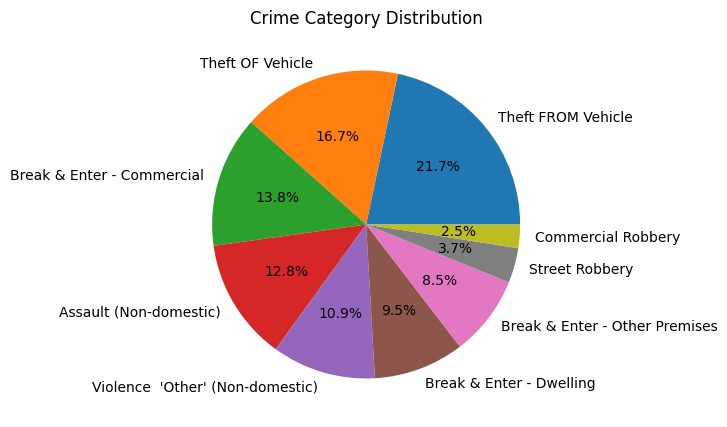

In [31]:
plt.figure(figsize = (5, 5))
df['Category'].value_counts().plot.pie(autopct = '%1.1f%%')
plt.title('Crime Category Distribution')
plt.ylabel('')

This graph shows the distribution of crimes in each category by the number of crimes. The top crime category is Theft from Vehicle with 21.7% of the total crimes, followed by Theft of Vehicle with 16.7% and Break and Enter - Commercial with 13.8%. The least crime category inc;udes commerical or street robbery.

### Crime Reporting Over the Years

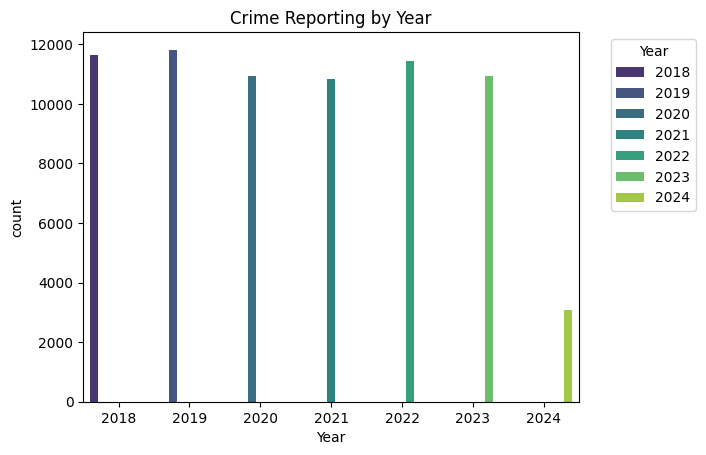

In [34]:
sns.countplot(x = 'Year', data = df, hue = 'Year', palette = 'viridis').set_title('Crime Reporting by Year')       

# Move the legend outside the plot (to the right)
plt.legend(title = 'Year', bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.tight_layout
plt.show()

This bar graph shows the distribution of number of crimes reported in the year. The year 2019 had the highest reportings of crimes followed by 2022 and 2018. The crime reportings in 2024 are less due to limited data till April 2024.

### Crime Reportings by Month

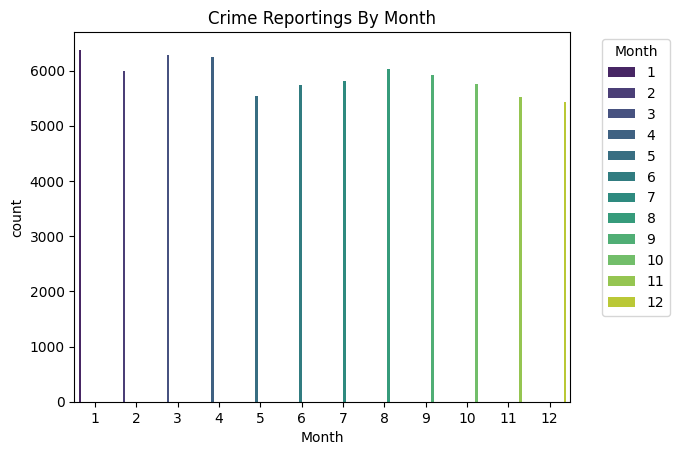

In [37]:
sns.countplot(x = 'Month', data = df, hue = 'Month', palette = 'viridis').set_title('Crime Reportings By Month')

# Move the legend outside the plot (to the right)
plt.legend(title = 'Month', bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.tight_layout
plt.show()

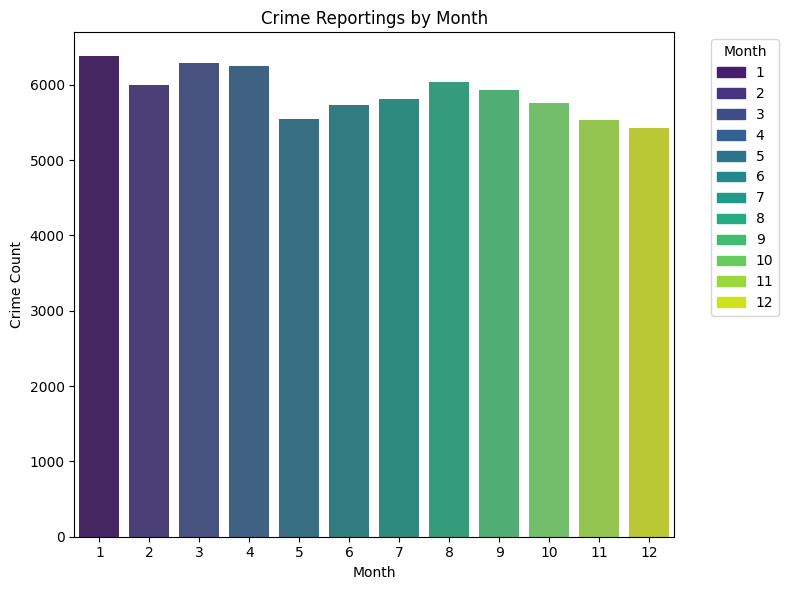

In [39]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
sns.countplot(x='Month', data=df, palette='viridis')
plt.title('Crime Reportings by Month')
plt.xlabel('Month')
plt.ylabel('Crime Count')

# Create manual legend with colors matching 'viridis'
colors = sns.color_palette('viridis', df['Month'].nunique())
handles = [mpatches.Patch(color=colors[i], label=str(month)) for i, month in enumerate(sorted(df['Month'].unique()))]

plt.legend(handles=handles, title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Community and Category Analysis

In [41]:
plt.figure(figsize = (15, 5))
sns.countplot(x = 'Community', data = df, hue = 'Category', palette = 'viridis', 
              order = df['Community'].value_counts().head(5).index).set_title
              ('Top 5 Most dangerous Community and Crime Category')
sns.move_legend(plt.gca(), "upper right")
plt.figure(
                                                                              
              

SyntaxError: incomplete input (2493133270.py, line 2)